<div align="center">

<img src="https://raw.githubusercontent.com/winstonsmith1897/DantinoX/main/docs/images/dantinox.png" width="150" alt="DantinoX"/>

</div>

# DantinoX · 05 — LoRA Fine-Tuning

<div align="center">

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/winstonsmith1897/DantinoX/blob/main/docs/notebooks/05_lora_fine_tuning.ipynb) &nbsp;
[![PyPI](https://img.shields.io/pypi/v/dantinox?color=7c3aed)](https://pypi.org/project/dantinox/) &nbsp;
[![GitHub](https://img.shields.io/badge/GitHub-DantinoX-181717?logo=github)](https://github.com/winstonsmith1897/DantinoX)

</div>

*Low-Rank Adaptation — train tiny adapters on a frozen base model, then merge for zero-overhead inference.*

---

**You’ll learn**
- `use_lora=True` — inject rank-`r` adapters into frozen weights
- `lora_targets` — attention · ffn · all
- `lora_rank` / `lora_alpha` — adapter capacity & scaling
- `merge_lora()` — fold adapters into base weights for inference

**Runtime** — GPU (T4 or better)

---

In [ ]:
!pip install -q uv
!uv pip install --system -q -U "dantinox[data,hub,elf,benchmark]" "flax>=0.12,<0.13" "jax[cuda12]"

In [1]:
import dantinox as dx

dx.doctor()   # environment health check — jax/flax/CUDA alignment, GPU visibility

  warnings.warn(



  ████                █    █                █   █
  █   █  ███  ████  █████       ████   ███   █ █ 
  █   █ █   █ █   █   █    █    █   █ █   █   █  
  █   █ █  ██ █   █   █    █    █   █ █   █  █ █ 
  ████   ████ █   █   ██   ███  █   █  ███  █   █

  JAX/Flax transformer library  v0.4.7



E0715 11:30:24.961445 2500418 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 29.62GiB (31803604992 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0715 11:30:24.962182 2500418 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 26.66GiB (28623243264 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0715 11:30:24.962865 2500418 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 23.99GiB (25760917504 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0715 11:30:24.963545 2500418 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 21.59GiB (23184824320 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0715 11:30:24.964221 2500418 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 19.43GiB (20866340864 by

DantinoX doctor
  dantinox             0.4.7
  jax                  0.9.2
  jaxlib               0.9.2
  flax                 0.12.6
  optax                0.2.8
  jax-cuda12-plugin    0.10.0
  jax-cuda12-pjrt      0.10.0
  transformers         4.44.2
  datasets             4.8.5
  devices              cuda:0
  ✗ jax-cuda12-plugin 0.10.0 vs jaxlib 0.9.2 — the CUDA plugin must match jaxlib exactly (PJRT errors otherwise); fix: pip install -U "jax[cuda12]"


{'versions': {'dantinox': '0.4.7',
  'jax': '0.9.2',
  'jaxlib': '0.9.2',
  'flax': '0.12.6',
  'optax': '0.2.8',
  'jax-cuda12-plugin': '0.10.0',
  'jax-cuda12-pjrt': '0.10.0',
  'transformers': '4.44.2',
  'datasets': '4.8.5'},
 'problems': ['jax-cuda12-plugin 0.10.0 vs jaxlib 0.9.2 — the CUDA plugin must match jaxlib exactly (PJRT errors otherwise); fix: pip install -U "jax[cuda12]"'],
 'warnings': [],
 'gpu': ['cuda:0'],
 'ok': False}

In [2]:
import os
import urllib.request

if not os.path.exists('tiny_shakespeare.txt'):
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt',
        'tiny_shakespeare.txt')

if not os.path.exists('bible.txt'):
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/mxw/grmr/master/src/finaltests/bible.txt',
        'bible.txt')

print('Data ready.')

Data ready.


## 1. Pre-train a Base Model

Train a small AR model on Tiny Shakespeare. We'll fine-tune it on Biblical text to demonstrate domain adaptation.

In [3]:
import dantinox as dx

base_run = dx.fit(
    'ar', 'tiny_shakespeare.txt',
    dim=256, n_heads=4, head_size=64, num_blocks=4,
    lr=3e-4, epochs=2, batch_size=16,
)
print('Base model checkpoint:', base_run)


  ──────────────────────────────────────────────────────────────
  ar  ·  causal
  ──────────────────────────────────────────────────────────────
  run dir       runs/20260715_113026
  parameters    4.2 M  (4,223,744)

  ── model ─────────────────────────────────────────────────────
  256-dim  ·  4h×64  ·  4 blocks  ·  vocab=66  ·  ctx=512
  MHA  ·  RoPE  ·  RMSNorm  ·  causal  ·  MLP(×4,SwiGLU)

  ── data ──────────────────────────────────────────────────────
  source        tiny_shakespeare.txt
  tokenizer     char  ·  66 vocab
  tokens        1,115,394  (train 1,003,855  ·  val 111,539)

  ── training ──────────────────────────────────────────────────
  optimizer     adamw  ·  lr=3e-04  ·  cosine  ·  warmup=400
  batch         16
  schedule      2 epochs  ·  122 steps/epoch  ·  244 updates
  precision     fp32
  devices       1× GPU

  ──────────────────────────────────────────────────────────────



  ⚠  only 244 optimizer updates — the model will likely be undertrained; lower batch_size or raise epochs


  step 1: JIT compiling (may take 1-3 min on first run)...


  from .autonotebook import tqdm as notebook_tqdm


Epoch 1/2:   0%|          | 0/122 [00:00<?, ?it/s]

...

Epoch 2/2:  91%|█████████ | 111/122 [00:03<00:00, 33.78it/s, loss=1.7924]

Epoch 2/2:  99%|█████████▉| 121/122 [00:03<00:00, 34.56it/s, loss=1.7924]

  Epoch 2/2  train=1.8604  val=1.8993 (ppl 6.7)  ★ best  3.5s  287.6k tok/s



  ──────────────────────────────────────────────────────────────
  training complete  ·  best val loss = 1.8993
  saved → runs/20260715_113026
  ──────────────────────────────────────────────────────────────



Base model checkpoint: runs/20260715_113026


## 2. LoRA Configuration

Set `use_lora=True` in `ModelConfig` to activate LoRA. The base model's learned weights remain **frozen**; only the tiny adapter matrices `A` and `B` are trained.

```
W_effective = W_base (frozen) + (α/r) · B @ A
```

At init `B = 0`, so the adapter starts as an identity perturbation.

In [4]:
import dataclasses

import jax
from flax import nnx

from dantinox.core.lora import LoRAParam


def lora_stats(cfg):
    """Build a model and return (total_params, lora_params, lora_pct)."""
    m  = dx.Paradigm(cfg).build_model(nnx.Rngs(0))
    ap = nnx.state(m, nnx.Param)
    lp = nnx.state(m, LoRAParam)
    total = sum(x.size for x in jax.tree_util.tree_leaves(ap))
    lora  = sum(x.size for x in jax.tree_util.tree_leaves(lp))
    return total, lora, 100 * lora / max(total, 1)

base_cfg = dx.ModelConfig(paradigm="ar", dim=256, n_heads=4, head_size=64, num_blocks=4,
                           vocab_size=200)

print(f'{"Config":30s}  {"Total":>10s}  {"LoRA":>8s}  {"LoRA%":>6s}')
for rank in (2, 4, 8, 16):
    cfg = dataclasses.replace(base_cfg, use_lora=True,
                               lora_rank=rank, lora_alpha=float(rank*2),
                               lora_targets='attention', lora_dropout=0.0)
    t, l, p = lora_stats(cfg)
    print(f'attention r={rank:2d}                  {t/1e6:>8.2f}M  {l/1e3:>6.1f}K  {p:>6.3f}%')

Config                               Total      LoRA   LoRA%


attention r= 2                      4.26M    12.3K   0.289%


attention r= 4                      4.26M    24.6K   0.577%


attention r= 8                      4.26M    49.2K   1.155%


attention r=16                      4.26M    98.3K   2.309%


## 3. LoRA Targets

`lora_targets` controls which weight matrices receive adapters:

| Value | Adapters injected into |
|---|---|
| `'attention'` | Q, K, V, O projections |
| `'ffn'` | FFN up/down/gate projections |
| `'all'` | attention + FFN |

In [5]:
print(f'{"lora_targets":12s}  {"Total":>10s}  {"LoRA":>8s}  {"LoRA%":>6s}')
for target in ('attention', 'ffn', 'all'):
    cfg = dataclasses.replace(base_cfg, use_lora=True, lora_rank=8, lora_alpha=16.0,
                               lora_targets=target, lora_dropout=0.0)
    t, l, p = lora_stats(cfg)
    print(f'{target:12s}  {t/1e6:>8.2f}M  {l/1e3:>6.1f}K  {p:>6.3f}%')

lora_targets       Total      LoRA   LoRA%


attention         4.26M    49.2K   1.155%


ffn               4.25M   114.7K   2.699%


all               4.25M   163.8K   3.857%


## 4. Fine-Tuning with LoRA

The `Trainer` automatically detects `use_lora=True` and freezes base weights. Only the LoRA adapters are passed to the optimizer.

In [6]:
lora_cfg = dx.ModelConfig(
    paradigm="ar",
    dim=256, n_heads=4, head_size=64, num_blocks=4,
    use_lora     = True,
    lora_rank    = 8,
    lora_alpha   = 16.0,
    lora_targets = 'attention',
    lora_dropout = 0.05,
)

ft_run = dx.Trainer(
    dx.Paradigm(lora_cfg),
    dx.TrainingConfig(lr=1e-3, epochs=2, batch_size=16),
).fit('bible.txt')
print('Fine-tuned checkpoint:', ft_run)


  ──────────────────────────────────────────────────────────────
  ar  ·  causal
  ──────────────────────────────────────────────────────────────
  run dir       runs/20260715_113106
  parameters    4.2 M  (4,226,560)

  ── model ─────────────────────────────────────────────────────
  256-dim  ·  4h×64  ·  4 blocks  ·  vocab=81  ·  ctx=512
  MHA  ·  RoPE  ·  RMSNorm  ·  causal  ·  MLP(×4,SwiGLU)
  LoRA(r=8, α=16.0)

  ── data ──────────────────────────────────────────────────────
  source        bible.txt
  tokenizer     char  ·  81 vocab
  tokens        4,351,186  (train 3,916,068  ·  val 435,118)

  ── training ──────────────────────────────────────────────────
  optimizer     adamw  ·  lr=1e-03  ·  cosine  ·  warmup=400
  batch         16
  schedule      2 epochs  ·  478 steps/epoch  ·  956 updates
  precision     fp32
  devices       1× GPU

  ──────────────────────────────────────────────────────────────



  step 1: JIT compiling (may take 1-3 min on first run)...


Epoch 1/2:   0%|          | 0/478 [00:00<?, ?it/s]

  vram 0.0 GB used  ·  peak 1.3/30 GB (4%)


Epoch 1/2:   0%|          | 0/478 [00:16<?, ?it/s, loss=4.9541]

...

Epoch 2/2:  98%|█████████▊| 467/478 [00:11<00:00, 43.49it/s, loss=1.9219]

Epoch 2/2:  99%|█████████▊| 472/478 [00:11<00:00, 39.34it/s, loss=1.9219]

  Epoch 2/2  train=1.8697  val=2.0133 (ppl 7.5)  ★ best  11.8s  330.8k tok/s



  ──────────────────────────────────────────────────────────────
  training complete  ·  best val loss = 2.0133
  saved → runs/20260715_113106
  ──────────────────────────────────────────────────────────────



Fine-tuned checkpoint: runs/20260715_113106


## 5. Compare Base vs Fine-Tuned Generation

In [7]:
prompt = 'In the beginning'

print('=== Base model (Tiny Shakespeare domain) ===')
print(dx.quick_generate(base_run, prompt, max_new_tokens=150))

print('\n=== LoRA fine-tuned (Bible domain) ===')
print(dx.quick_generate(ft_run, prompt, max_new_tokens=150,
                        paradigm=dx.Paradigm(lora_cfg)))

=== Base model (Tiny Shakespeare domain) ===


In the beginning ETear epartier,
in I'll KIsear toge-peer, charn is brise
Marnal you you night rethanoh my slelace beit.

DUCKING OF IU?
Nor so that lord.

KINREND da

=== LoRA fine-tuned (Bible domain) ===


In the beginning it wh/o
thut he mous for unto )rd; it jI dahe EribeasNait. 

19:C0 Thee not LORD he dly linghBeg: falt a that cas of the chat treaving the be lhadgba


## 6. Merging Adapters

`merge_lora()` folds `(α/r)·B·A` into the base weight `W`, producing a standard model with zero adapter overhead at inference.

In [8]:
from dantinox.core.lora import merge_lora

# Load the fine-tuned LoRA model
lora_model = dx.load(ft_run, paradigm=dx.Paradigm(lora_cfg))

# Merge: returns a standard Transformer (no LoRA layers)
merged = merge_lora(lora_model)

total_lora   = sum(x.size for x in jax.tree_util.tree_leaves(nnx.state(lora_model, nnx.Param)))
total_merged = sum(x.size for x in jax.tree_util.tree_leaves(nnx.state(merged, nnx.Param)))
print(f'LoRA model params (Param): {total_lora:,}')
print(f'Merged model params:       {total_merged:,}')
print(f'Overhead removed:          {total_lora - total_merged:,} LoRA-only params')

LoRA model params (Param): 4,226,560
Merged model params:       4,226,560
Overhead removed:          0 LoRA-only params


## 7. Using `dataclasses.replace` for Config Variants

The cleanest way to create LoRA variants of an existing config:

In [9]:
import dataclasses

base_model_cfg = dx.ModelConfig(paradigm="ar", dim=256, n_heads=4, head_size=64, num_blocks=4)

# Attention-only LoRA
attn_lora_cfg = dataclasses.replace(
    base_model_cfg,
    use_lora=True, lora_rank=8, lora_alpha=16.0,
    lora_targets='attention', lora_dropout=0.0,
)

# FFN-only LoRA
ffn_lora_cfg = dataclasses.replace(
    base_model_cfg,
    use_lora=True, lora_rank=4, lora_alpha=8.0,
    lora_targets='ffn', lora_dropout=0.0,
)

for name, cfg in [('Attention LoRA', attn_lora_cfg), ('FFN LoRA', ffn_lora_cfg)]:
    rd = dx.Trainer(
        dx.Paradigm(cfg),
        dx.TrainingConfig(lr=1e-3, epochs=1, batch_size=16),
    ).fit('bible.txt', run_dir=f'/tmp/lora_{name.replace(" ", "_").lower()}')
    print(f'{name}: {dx.quick_generate(rd, prompt, max_new_tokens=60)[:80]}')


  ──────────────────────────────────────────────────────────────
  ar  ·  causal
  ──────────────────────────────────────────────────────────────
  run dir       /tmp/lora_attention_lora
  parameters    4.2 M  (4,226,560)

  ── model ─────────────────────────────────────────────────────
  256-dim  ·  4h×64  ·  4 blocks  ·  vocab=81  ·  ctx=512
  MHA  ·  RoPE  ·  RMSNorm  ·  causal  ·  MLP(×4,SwiGLU)
  LoRA(r=8, α=16.0)

  ── data ──────────────────────────────────────────────────────
  source        bible.txt
  tokenizer     char  ·  81 vocab
  tokens        4,351,186  (train 3,916,068  ·  val 435,118)

  ── training ──────────────────────────────────────────────────
  optimizer     adamw  ·  lr=1e-03  ·  cosine  ·  warmup=400
  batch         16
  schedule      1 epoch  ·  478 steps/epoch  ·  478 updates
  precision     fp32
  devices       1× GPU

  ──────────────────────────────────────────────────────────────



  ⚠  only 478 optimizer updates — the model will likely be undertrained; lower batch_size or raise epochs


  step 1: JIT compiling (may take 1-3 min on first run)...


Epoch 1/1:   0%|          | 0/478 [00:00<?, ?it/s]

  vram 0.0 GB used  ·  peak 1.3/30 GB (4%)


...

Epoch 1/1:  97%|█████████▋| 465/478 [00:27<00:00, 42.52it/s, loss=2.4474]

Epoch 1/1:  99%|█████████▊| 471/478 [00:27<00:00, 37.58it/s, loss=2.4474]

  Epoch 1/1  train=2.6960  val=2.5110 (ppl 12.3)  ★ best  12.2s (+15.1s compile)  320.6k tok/s



  ──────────────────────────────────────────────────────────────
  training complete  ·  best val loss = 2.5110
  saved → /tmp/lora_ffn_lora
  ──────────────────────────────────────────────────────────────



FFN LoRA: In the beginningeaerrey are:owamlTotito Y9evtedaxtetyaPate sshesthathasamvor


## 8. Rank Ablation

Sweep over different LoRA ranks to study the tradeoff between adapter capacity and parameter budget.

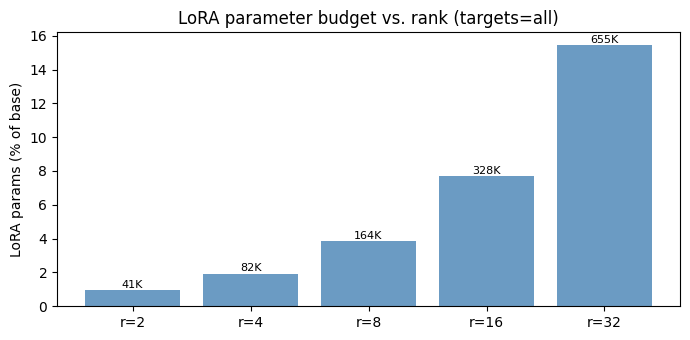

In [10]:
import matplotlib.pyplot as plt

ranks = [2, 4, 8, 16, 32]
lora_counts = []
pcts = []

base_total, _, _ = lora_stats(base_cfg)
for r in ranks:
    cfg = dataclasses.replace(base_cfg, use_lora=True,
                               lora_rank=r, lora_alpha=float(r*2),
                               lora_targets='all', lora_dropout=0.0)
    _, lora_n, lora_p = lora_stats(cfg)
    lora_counts.append(lora_n)
    pcts.append(lora_p)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(range(len(ranks)), pcts, color='steelblue', alpha=0.8)
ax.set_xticks(range(len(ranks)))
ax.set_xticklabels([f'r={r}' for r in ranks])
ax.set_ylabel('LoRA params (% of base)')
ax.set_title('LoRA parameter budget vs. rank (targets=all)')
for i, (p, n) in enumerate(zip(pcts, lora_counts)):
    ax.text(i, p + 0.01, f'{n/1e3:.0f}K', ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()

---

**Recap** — you learned:
- injecting rank-`r` adapters into a frozen base model
- choosing `lora_targets` / `lora_rank` / `lora_alpha`
- merging adapters for zero-overhead inference

**Next →** [06 · Paradigm Profiling](06_paradigm_profiling.ipynb) · [Open in Colab](https://colab.research.google.com/github/winstonsmith1897/DantinoX/blob/main/docs/notebooks/06_paradigm_profiling.ipynb)